# Experiment 2 – Perceptual decisions (dot numerosity): GOAL model fit (Gamma prior)

Fits the Goal-oriented Asymmetric Likelihood (GOAL) model separately to each goal frame.

- **Data:** `DataPerceptualFramingNotebook.csv`; frames `BlockCond == "MORE"` (Most) and `"LESS"` (Fewest) (evidence = number of dots in the left/right patch).
- **Model:** Gamma priors on the belief SDs, Gamma(α = 6, β = 1.2) – robustness check (Figure S3). Means of the low/high belief distributions are fixed from a median split of the evidence; choice and confidence (with RT) are observed.
- **Fitting:** even-numbered trials, PyMC NUTS, 4 chains × 4000 draws (1000 tuning).
- **Output:** posterior traces saved as `.nc` files, used by `Figure_exp1-4_ModelFit_GammaPrior.ipynb` to simulate held-out trials and make the figures.

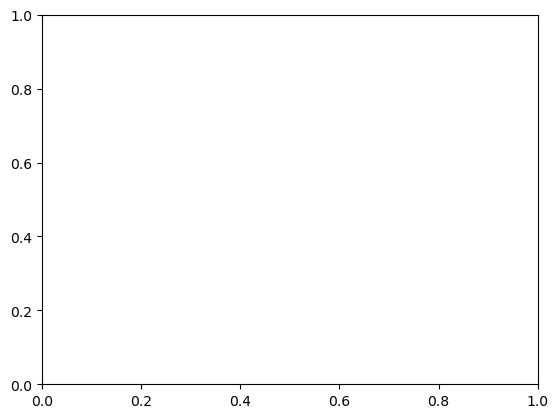

In [1]:
import pymc as pm
import pandas as pd
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import  pytensor.tensor as pt

import functionsSims as fs

In [2]:
def mainLoad(data_part_all0):
    # Prepare one frame: z-score within participant, split even/odd trials,
    # extract model inputs and plot the evidence/confidence distributions

    # z-score values
    data_part_all0['zLValue'] = fs.zscore1(data_part_all0,'LValue', 'Part')
    data_part_all0['zRValue'] = fs.zscore1(data_part_all0,'RValue', 'Part')
    data_part_all0['zConf'] = fs.zscore1(data_part_all0,'Conf', 'Part')
    data_part_all0['zRT'] = fs.zscore1(data_part_all0,'ChoiceRT', 'Part')

    # estimate choice and confidence compound
    data_part_all0['choiceConf'] = data_part_all0.Conf * (2*data_part_all0.ChosenITM-1) # second term is to transform choice to left : -1; right: +1
    data_part_all0['zChoiceConf'] = fs.zscore1(data_part_all0,'choiceConf', 'Part')

    # Split trials: model fitted to even trials, odd trials kept as test set
    data_part_all = data_part_all0.loc[data_part_all0.TrialN%2 == 0]
    data_part_all_test = data_part_all0.loc[data_part_all0.TrialN%2 == 1]

    # load input 
    val_a = data_part_all.zLValue.values
    val_b = data_part_all.zRValue.values
    chosenByPart = data_part_all.ChosenITM.values
    rtByPart = data_part_all.zRT.values

    # generate all values to be sorted to generate high and low value distributions
    value_sort = data_part_all.copy()
    value_sort = value_sort.zLValue.values

    confByPart = data_part_all.zConf.values
    choiceConfByPart = data_part_all.zChoiceConf.values

    confNormByPart = fs.norm01(data_part_all,'zConf','Part')

    delta_og = data_part_all.zLValue
    delta_og.hist()
    plt.title(r"Distribution of values from participant")
    print('mean of the value distribution: ' + str(val_a.mean()))
    print('std of the value distribution: ' + str(val_a.std()))
    plt.show()

    val_og = data_part_all.zLValue
    conf_og = data_part_all.zConf
    conf_og.hist()
    plt.title(r"Distribution of confidence from participant (zScored)")
    print('mean of the confidence distribution: ' + str(conf_og.mean()))
    print('std of the confidence distribution: ' + str(conf_og.std()))
    plt.show()

    choiceConf_og = data_part_all0['Conf'] 
    plt.hist(choiceConf_og)
    plt.title(r"Distribution of zscored confidence from participant")
    print('mean : ' + str(np.mean(choiceConf_og)))
    print('std  : ' + str(np.std(choiceConf_og)))
    plt.show()

    choiceConf_og = confNormByPart
    plt.hist(choiceConf_og)
    plt.title(r"Distribution of normalized 0-1 confidence from participant")
    print('mean : ' + str(np.mean(choiceConf_og)))
    print('std  : ' + str(np.std(choiceConf_og)))
    plt.show()

    # Means of the low/high evidence distributions from a median split of the evidence (Figure S2)
    lvalParam, hvalParam = fs.split_values_highLow (value_sort)

    return val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test   

In [4]:
data_all = pd.read_csv('../Data/Sepulveda2020/DataPerceptualFramingNotebook.csv') 

# Fewest frame (choose fewer dots)

mean of the value distribution: 0.010404449373698
std of the value distribution: 0.954696819670808


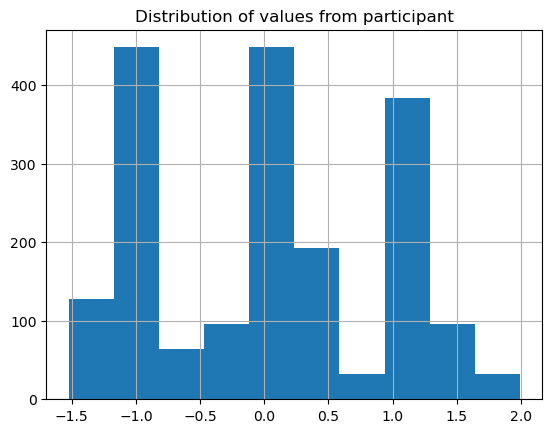

mean of the confidence distribution: -0.056572608812344945
std of the confidence distribution: 1.0112128186192795


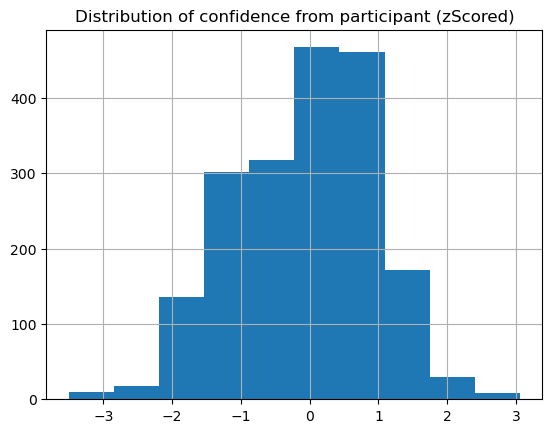

mean : 52.78333333333333
std  : 27.09917997939339


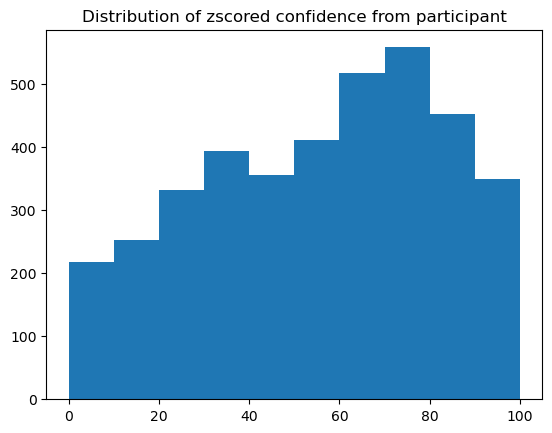

mean : 0.5160861330319865
std  : 0.28527039914576713


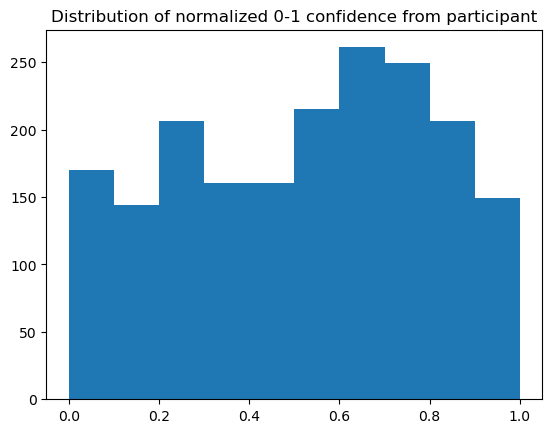

mean values -> high: 0.551336478887459 ,  low:-0.7816342591990628
stdev values -> high: 0.551336478887459 ,  low:0.5137262728786748
low values distribution: mean:-0.7816342591990628, var:0.5137262728786748
high values distribution: mean:0.8032799078504699, var:0.551336478887459


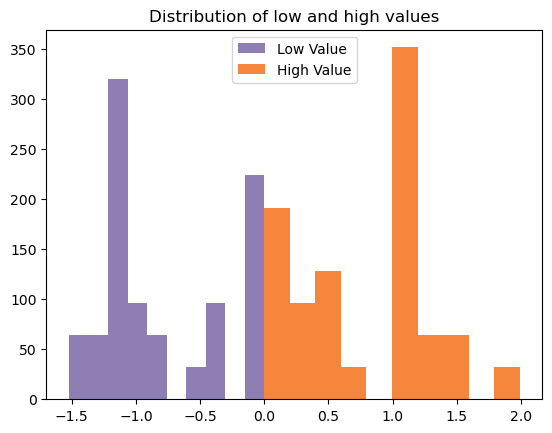

In [6]:
data_part_all0 =  data_all.loc[data_all.BlockCond == 'LESS'] # Fewest frame

val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad(data_part_all0)

In [7]:
n_trials = len (val_a)
RANDOM_SEED = 58
rng = np.random.default_rng(RANDOM_SEED)

# Fixed means of the low (mu[0]) and high (mu[1]) evidence belief distributions
mu = [lvalParam[0],hvalParam[0]]
for i in range(1):

    print ('running sim repetition '+ str(i) )
    
    with pm.Model() as model_peb2:
        # Free parameters: SDs of the belief distributions (sigmaBel1: low-evidence, sigmaBel2: high-evidence category)
        sigmaGen1 = pm.Gamma('sigmaBel1', alpha=6, beta=1.2)  # mean ≈5, mode away from 0
        sigmaGen2 = pm.Gamma('sigmaBel2', alpha=6, beta=1.2)
        
        # Observed (z-scored) evidence for the left/right option on each trial
        lVal = pm.Normal('lVal', mu = val_a, sigma = 0.001 , shape = n_trials)
        rVal = pm.Normal('rVal', mu = val_b, sigma = 0.001  , shape = n_trials)

        # Log-likelihood ratio that <right, left> = <high, low> rather than <low, high> evidence
        # (Gaussian belief distributions with means mu and SDs sigmaGen1/sigmaGen2)
        LLR = pm.Deterministic('LLR',  pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.)))) - 
                                       pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) + 
                                       pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) -
                                       pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.))))  )

        # Choice: logistic function of the LLR; beta scales its influence (prior precision tau = 0.001)
        beta = pm.Normal("beta", mu=0, tau=0.001, testval=0)
        p = pm.Deterministic("p", 1.0/(1. + pt.exp(beta*LLR) ))    
        
        choice = pm.Bernoulli("choice", p, observed=chosenByPart)

        # Confidence: logistic function of |LLR| and RT, weighted by betaConf and betaRT
        betaConf = pm.Normal("betaConf", mu=0, tau=0.001, testval=0)      
        betaRT = pm.Normal("betaRT", mu=0, tau=0.001, testval=0)
        
        conf = pm.Deterministic("conf",1.0/(1. + pt.exp(betaConf*pt.abs(LLR) + betaRT*rtByPart)) )

        # Reported confidence (normalised 0-1 per participant) with small noise (sigma = 0.025)
        confRep = pm.Normal('confReport',mu = conf, sigma=0.025, observed=confNormByPart)  

    # MCMC settings: 4 chains x 4000 draws (NUTS), 1000 tuning steps
    nsample = 4000
    nchains = 4
    

running sim repetition 0


In [8]:
with model_peb2:
    
    # Prior predictive samples, then posterior sampling with NUTS
    trace2 = pm.sample_prior_predictive( random_seed=rng)
    trace2.extend(pm.sample(nsample, cores=4,tune=1000, chains=nchains, return_inferencedata=True))

Sampling: [beta, betaConf, betaRT, choice, confReport, lVal, rVal, sigmaBel1, sigmaBel2]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigmaBel1, sigmaBel2, lVal, rVal, beta, betaConf, betaRT]


Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 2379 seconds.


In [10]:
# Save posterior (loaded by Figure_exp1-4_ModelFit_*.ipynb)
trace2.to_netcdf("sample_exp2_less_gamma.nc")

'sample_exp2_less_gamma.nc'

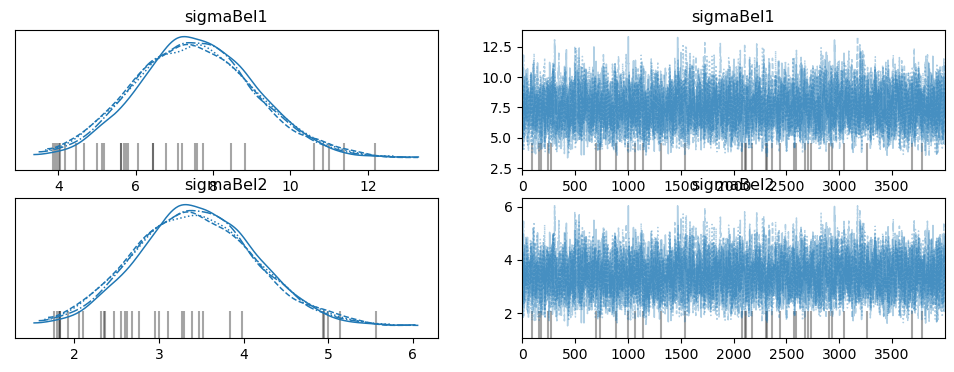

In [11]:
# Convergence check: trace plots
az.plot_trace(trace2, var_names=['sigmaBel1', 'sigmaBel2']);

In [12]:
# Convergence check: Gelman-Rubin R-hat
rhats_params = az.rhat(trace2, method="folded")
rhats_params

<xarray.Dataset>
Dimensions:     (lVal_dim_0: 1920, rVal_dim_0: 1920, LLR_dim_0: 1920,
                 p_dim_0: 1920, conf_dim_0: 1920)
Coordinates:
  * lVal_dim_0  (lVal_dim_0) int64 0 1 2 3 4 5 ... 1914 1915 1916 1917 1918 1919
  * rVal_dim_0  (rVal_dim_0) int64 0 1 2 3 4 5 ... 1914 1915 1916 1917 1918 1919
  * LLR_dim_0   (LLR_dim_0) int64 0 1 2 3 4 5 ... 1914 1915 1916 1917 1918 1919
  * p_dim_0     (p_dim_0) int64 0 1 2 3 4 5 6 ... 1914 1915 1916 1917 1918 1919
  * conf_dim_0  (conf_dim_0) int64 0 1 2 3 4 5 ... 1914 1915 1916 1917 1918 1919
Data variables:
    lVal        (lVal_dim_0) float64 1.0 1.0 1.0 1.0 0.9998 ... 1.0 1.0 1.0 1.0
    rVal        (rVal_dim_0) float64 1.0 1.0 1.0 1.0 ... 1.001 0.9999 1.0 1.0
    beta        float64 1.001
    betaConf    float64 1.001
    betaRT      float64 0.9998
    sigmaBel1   float64 1.001
    sigmaBel2   float64 1.001
    LLR         (LLR_dim_0) float64 1.001 1.001 1.001 ... 1.001 1.001 1.001
    p           (p_dim_0) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    conf        (conf_dim_0) float64 0.9999 0.9999 1.0 1.0 ... 1.0 0.9998 0.9999

Compare: Mean1 = 7.538265205663426; Mean2 = 3.437067169552286; [mean1 - mean2] =  4.10119803611114; t =  612.05 ; p-value =0.0


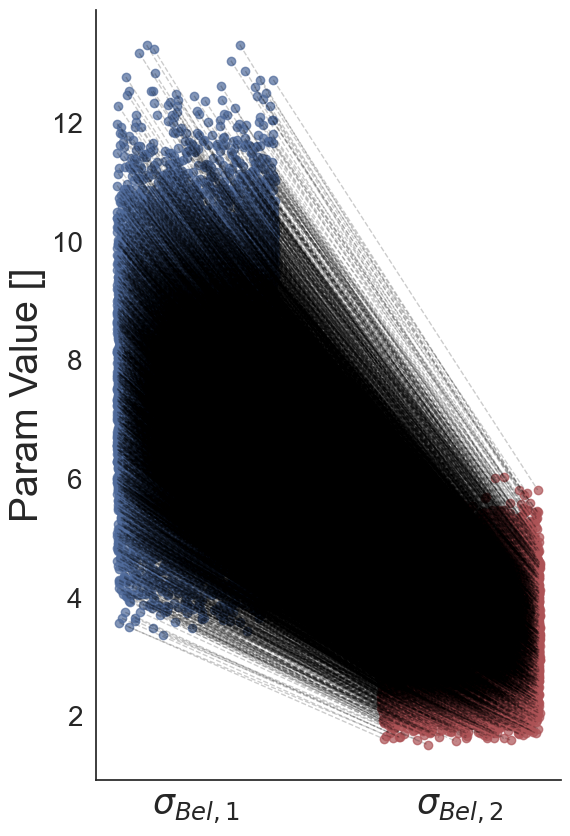

In [13]:
# Posterior of sigmaBel1 (low) vs sigmaBel2 (high)
fs.ttestsPlot(trace2.posterior['sigmaBel1'].values.flatten(), trace2.posterior['sigmaBel2'].values.flatten(),'#4F6A9A','#AC5255',"$\sigma_{Bel,1}$","$\sigma_{Bel,2}$",title = 'Param Value []')

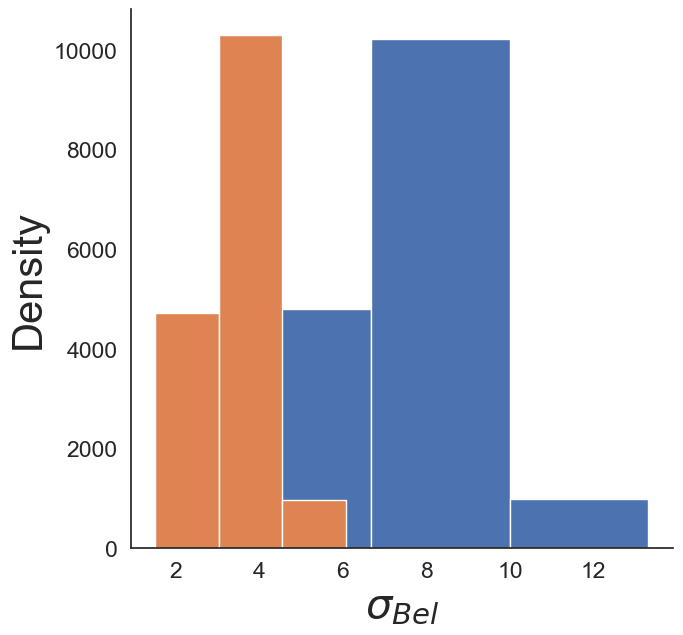

Proportion density above 0 : 0.0
Proportion density below 0 : 1.0
Mean sigmaBel1:7.538265205663426; SD sigmaBel1:1.5480276171176748
Mean sigmaBel2:3.437067169552286; SD sigmaBel2:0.7052570498359315
Delta sigmaBel mean:-4.101198036111139; SD:0.8475644915960269


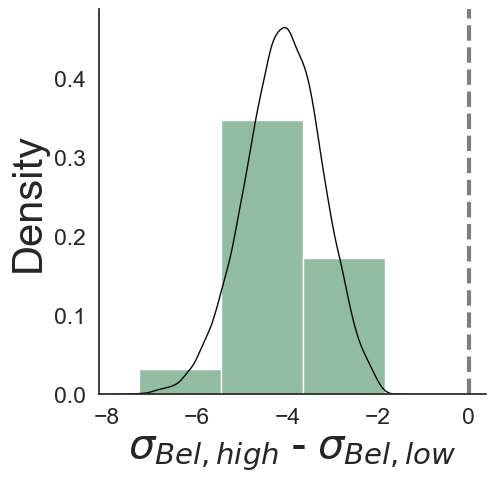

In [14]:
# Posterior of the belief-variance asymmetry (sigmaBel,high - sigmaBel,low)
fs.plotSigmaBelDensity(trace2, colorP = '#92BDA3',n_bins = 3,figName = 'figures/PEB_Model1RT_sigmaBelDensityLowMo_gamma.svg')

# Most frame (choose more dots)

mean of the value distribution: 0.010404449373698
std of the value distribution: 0.954696819670808


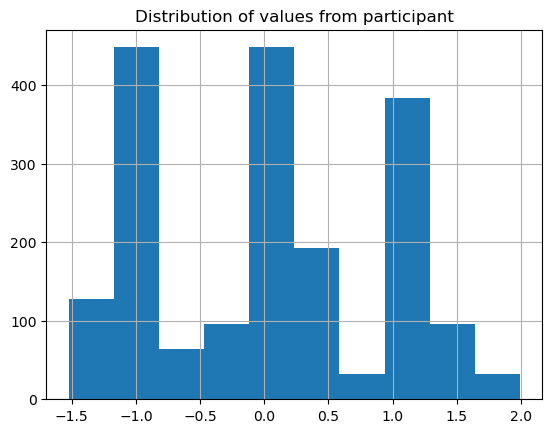

mean of the confidence distribution: -0.05057298653199507
std of the confidence distribution: 0.9889525256750724


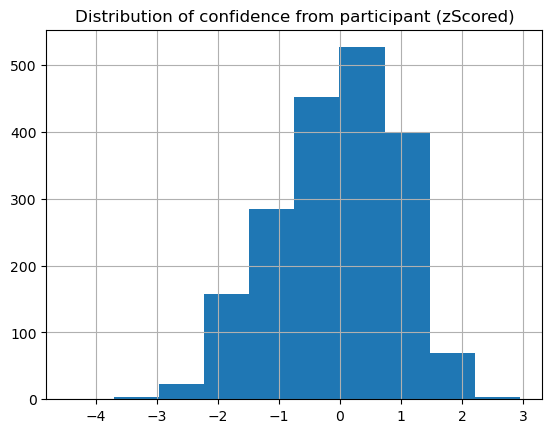

mean : 57.63489583333333
std  : 25.47778916260493


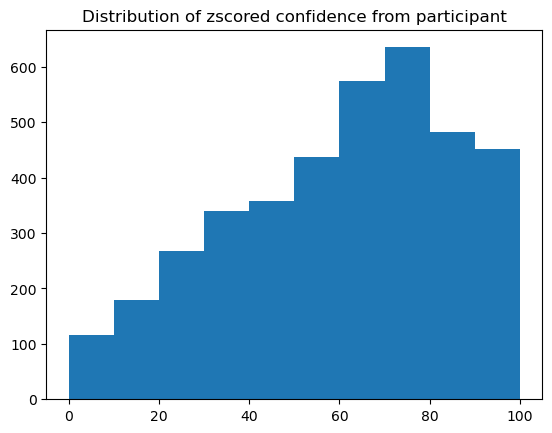

mean : 0.558876513967596
std  : 0.27288716289065046


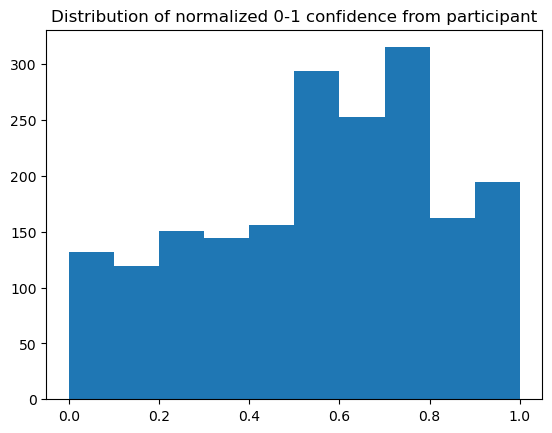

mean values -> high: 0.551336478887459 ,  low:-0.7816342591990628
stdev values -> high: 0.551336478887459 ,  low:0.5137262728786748
low values distribution: mean:-0.7816342591990628, var:0.5137262728786748
high values distribution: mean:0.8032799078504699, var:0.551336478887459


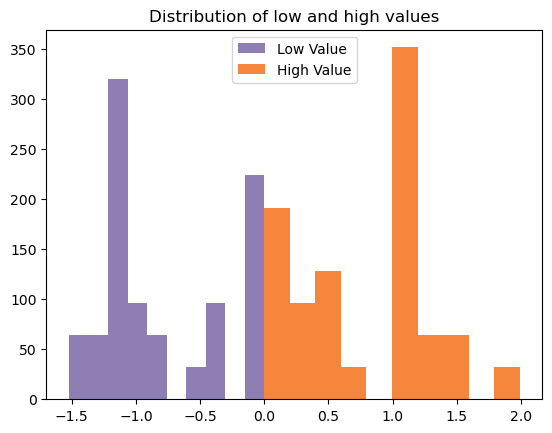

In [5]:
data_part_all0 =  data_all.loc[data_all.BlockCond == 'MORE'] # Most frame

val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad(data_part_all0)

In [6]:
n_trials = len (val_a)
RANDOM_SEED = 58
rng = np.random.default_rng(RANDOM_SEED)

# Fixed means of the low (mu[0]) and high (mu[1]) evidence belief distributions
mu = [lvalParam[0],hvalParam[0]]
for i in range(1):

    print ('running sim repetition '+ str(i) )
    
    with pm.Model() as model_peb2:
        # Free parameters: SDs of the belief distributions (sigmaBel1: low-evidence, sigmaBel2: high-evidence category)
        sigmaGen1 = pm.Gamma('sigmaBel1', alpha=6, beta=1.2)  # mean ≈5, mode away from 0
        sigmaGen2 = pm.Gamma('sigmaBel2', alpha=6, beta=1.2)
        
        # Observed (z-scored) evidence for the left/right option on each trial
        lVal = pm.Normal('lVal', mu = val_a, sigma = 0.001 , shape = n_trials)
        rVal = pm.Normal('rVal', mu = val_b, sigma = 0.001  , shape = n_trials)

        # Log-likelihood ratio that <right, left> = <high, low> rather than <low, high> evidence
        # (Gaussian belief distributions with means mu and SDs sigmaGen1/sigmaGen2)
        LLR = pm.Deterministic('LLR',  pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.)))) - 
                                       pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) + 
                                       pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) -
                                       pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.))))  )

        # Choice: logistic function of the LLR; beta scales its influence (prior precision tau = 0.001)
        beta = pm.Normal("beta", mu=0, tau=0.001, testval=0)
        p = pm.Deterministic("p", 1.0/(1. + pt.exp(beta*LLR) ))    
        
        choice = pm.Bernoulli("choice", p, observed=chosenByPart)

        # Confidence: logistic function of |LLR| and RT, weighted by betaConf and betaRT
        betaConf = pm.Normal("betaConf", mu=0, tau=0.001, testval=0)      
        betaRT = pm.Normal("betaRT", mu=0, tau=0.001, testval=0)
        
        conf = pm.Deterministic("conf",1.0/(1. + pt.exp(betaConf*pt.abs(LLR) + betaRT*rtByPart)) )

        # Reported confidence (normalised 0-1 per participant) with small noise (sigma = 0.025)
        confRep = pm.Normal('confReport',mu = conf, sigma=0.025, observed=confNormByPart)  

    # MCMC settings: 4 chains x 4000 draws (NUTS), 1000 tuning steps
    nsample = 4000
    nchains = 4
    

running sim repetition 0


In [7]:
with model_peb2:
    
    # Prior predictive samples, then posterior sampling with NUTS
    trace2 = pm.sample_prior_predictive( random_seed=rng)
    trace2.extend(pm.sample(nsample, cores=4,tune=1000, chains=nchains, return_inferencedata=True))

Sampling: [beta, betaConf, betaRT, choice, confReport, lVal, rVal, sigmaBel1, sigmaBel2]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigmaBel1, sigmaBel2, lVal, rVal, beta, betaConf, betaRT]


Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 1622 seconds.


In [8]:
# Save posterior (loaded by Figure_exp1-4_ModelFit_*.ipynb)
trace2.to_netcdf("sample_exp2_more_gamma.nc")

'sample_exp2_more_gamma.nc'

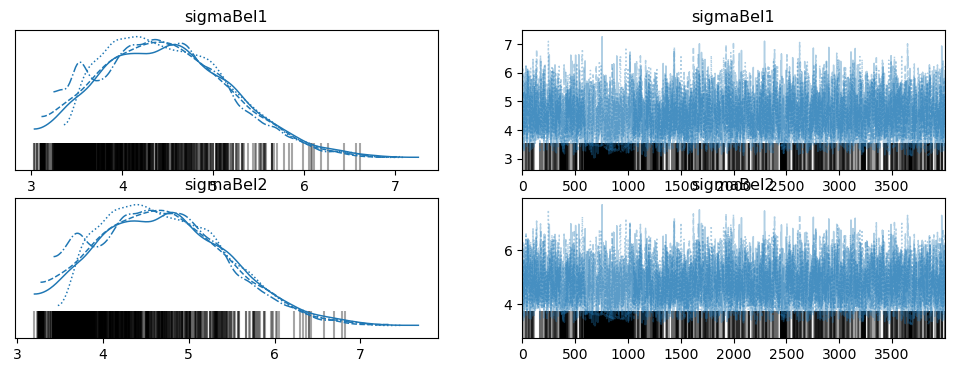

In [9]:
# Convergence check: trace plots
az.plot_trace(trace2, var_names=['sigmaBel1', 'sigmaBel2']);

In [10]:
# Convergence check: Gelman-Rubin R-hat
rhats_params = az.rhat(trace2, method="folded")
rhats_params

<xarray.Dataset>
Dimensions:     (lVal_dim_0: 1920, rVal_dim_0: 1920, LLR_dim_0: 1920,
                 p_dim_0: 1920, conf_dim_0: 1920)
Coordinates:
  * lVal_dim_0  (lVal_dim_0) int64 0 1 2 3 4 5 ... 1914 1915 1916 1917 1918 1919
  * rVal_dim_0  (rVal_dim_0) int64 0 1 2 3 4 5 ... 1914 1915 1916 1917 1918 1919
  * LLR_dim_0   (LLR_dim_0) int64 0 1 2 3 4 5 ... 1914 1915 1916 1917 1918 1919
  * p_dim_0     (p_dim_0) int64 0 1 2 3 4 5 6 ... 1914 1915 1916 1917 1918 1919
  * conf_dim_0  (conf_dim_0) int64 0 1 2 3 4 5 ... 1914 1915 1916 1917 1918 1919
Data variables:
    lVal        (lVal_dim_0) float64 1.0 1.004 1.009 1.003 ... 1.003 1.001 1.002
    rVal        (rVal_dim_0) float64 1.002 1.002 1.005 1.0 ... 1.003 1.0 1.004
    beta        float64 1.002
    betaConf    float64 1.002
    betaRT      float64 1.001
    sigmaBel1   float64 1.004
    sigmaBel2   float64 1.004
    LLR         (LLR_dim_0) float64 1.01 1.01 1.011 1.011 ... 1.011 1.01 1.01
    p           (p_dim_0) float64 1.001 1.001 1.001 1.001 ... 1.001 1.001 1.001
    conf        (conf_dim_0) float64 1.0 0.9999 1.004 1.0 ... 1.0 1.001 1.0

Compare: Mean1 = 4.482776963343284; Mean2 = 4.708065878278104; [mean1 - mean2] =  -0.22528891493482028; t =  -508.1 ; p-value =0.0


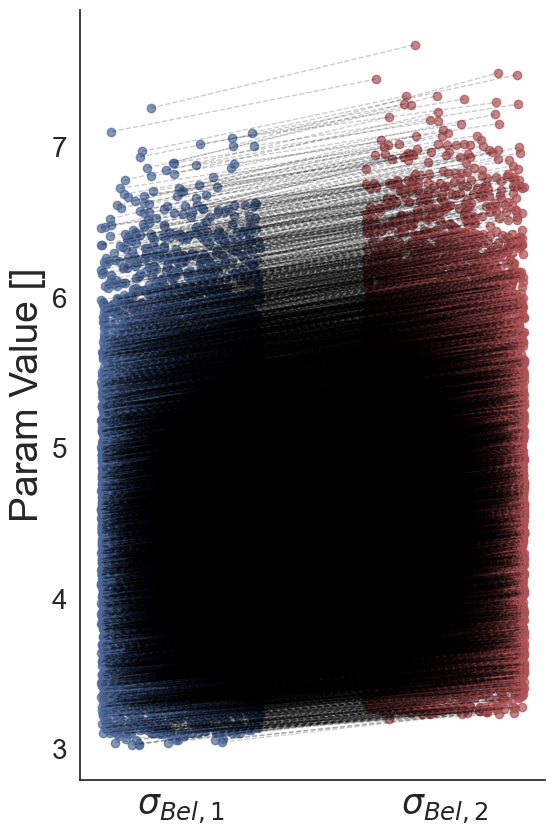

In [11]:
# Posterior of sigmaBel1 (low) vs sigmaBel2 (high)
fs.ttestsPlot(trace2.posterior['sigmaBel1'].values.flatten(), trace2.posterior['sigmaBel2'].values.flatten(),'#4F6A9A','#AC5255',"$\sigma_{Bel,1}$","$\sigma_{Bel,2}$",title = 'Param Value []')

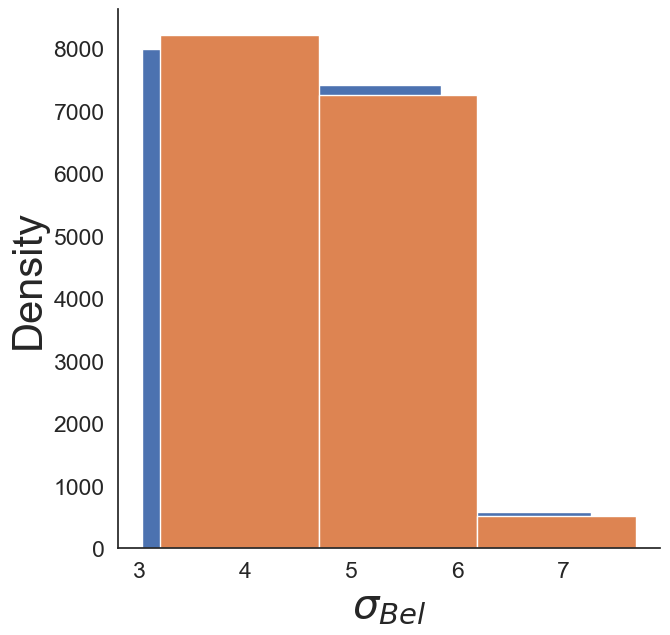

Proportion density above 0 : 1.0
Proportion density below 0 : 0.0
Mean sigmaBel1:4.482776963343284; SD sigmaBel1:0.7056705683991882
Mean sigmaBel2:4.708065878278104; SD sigmaBel2:0.7414246954676079
Delta sigmaBel mean:0.22528891493481953; SD:0.05608418479653055


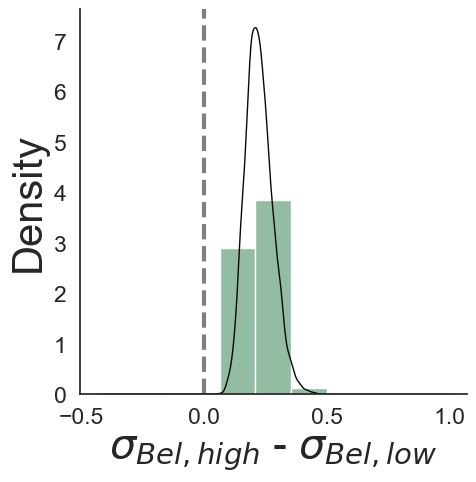

In [12]:
# Posterior of the belief-variance asymmetry (sigmaBel,high - sigmaBel,low)
fs.plotSigmaBelDensity(trace2, colorP = '#92BDA3',n_bins = 3,figName = 'figures/PEB_Model1RT_sigmaBelDensityLowMo_gamma.svg')